In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver

/home/hemant.agarwal/Desktop/Gen_AI/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [2]:
load_dotenv()

True

In [3]:
llm = ChatOpenAI(model="gpt-5-nano-2025-08-07")

In [4]:
class JokeState(TypedDict):

    topic: str
    joke: str
    explanation: str

In [5]:
def generate_joke(state: JokeState):

    prompt = f'generate a joke on the topic {state["topic"]}'
    response = llm.invoke(prompt).content

    return {'joke': response}

In [6]:
def generate_explanation(state: JokeState):

    prompt = f'write an explanation for the joke - {state["joke"]}'
    response = llm.invoke(prompt).content

    return {'explanation': response}

In [7]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

In [8]:
config1 = {"configurable": {"thread_id": "1"}}
workflow.invoke({'topic':'pizza'}, config=config1)

{'topic': 'pizza',
 'joke': 'Here are a few pizza-themed jokes you can pick from:\n\n- Why did the pizza apply for a loan? It needed the dough.\n- What do you call a fake pizza? An impasta.\n- Why did the pizza go to therapy? It had too much inner crust.',
 'explanation': 'Here are brief explanations for each joke and why they’re funny:\n\n- Why did the pizza apply for a loan? It needed the dough.\n  - Explanation: This joke plays on the double meaning of "dough" — literally the mixture used to make bread/pizza, and slang for money. The humor comes from treating a pizza as a person who would need money to get more dough, a playful bit of anthropomorphism plus a pun.\n\n- What do you call a fake pizza? An impasta.\n  - Explanation: This is a straightforward pun on "imposter"—replacing the "o" with "a" to form "impasta," which sounds like “im-pasta.” It’s funny because it blends the idea of a fake with a pasta-related word, tying it to pizza ingredients.\n\n- Why did the pizza go to ther

In [9]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Here are a few pizza-themed jokes you can pick from:\n\n- Why did the pizza apply for a loan? It needed the dough.\n- What do you call a fake pizza? An impasta.\n- Why did the pizza go to therapy? It had too much inner crust.', 'explanation': 'Here are brief explanations for each joke and why they’re funny:\n\n- Why did the pizza apply for a loan? It needed the dough.\n  - Explanation: This joke plays on the double meaning of "dough" — literally the mixture used to make bread/pizza, and slang for money. The humor comes from treating a pizza as a person who would need money to get more dough, a playful bit of anthropomorphism plus a pun.\n\n- What do you call a fake pizza? An impasta.\n  - Explanation: This is a straightforward pun on "imposter"—replacing the "o" with "a" to form "impasta," which sounds like “im-pasta.” It’s funny because it blends the idea of a fake with a pasta-related word, tying it to pizza ingredients.\n\n- Why did t

In [10]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Here are a few pizza-themed jokes you can pick from:\n\n- Why did the pizza apply for a loan? It needed the dough.\n- What do you call a fake pizza? An impasta.\n- Why did the pizza go to therapy? It had too much inner crust.', 'explanation': 'Here are brief explanations for each joke and why they’re funny:\n\n- Why did the pizza apply for a loan? It needed the dough.\n  - Explanation: This joke plays on the double meaning of "dough" — literally the mixture used to make bread/pizza, and slang for money. The humor comes from treating a pizza as a person who would need money to get more dough, a playful bit of anthropomorphism plus a pun.\n\n- What do you call a fake pizza? An impasta.\n  - Explanation: This is a straightforward pun on "imposter"—replacing the "o" with "a" to form "impasta," which sounds like “im-pasta.” It’s funny because it blends the idea of a fake with a pasta-related word, tying it to pizza ingredients.\n\n- Why did 

In [11]:
config2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({'topic':'pasta'}, config=config2)

{'topic': 'pasta',
 'joke': 'Here are a few pasta-themed jokes:\n\n- Why did the pasta break up with the sauce? It found the relationship too clingy.\n- What do you call a fake noodle? An impasta.\n- I’m on a pasta diet. I see pasta and I eat it.\n- Why did the spaghetti win the race? It was always ahead of the sauce.\n\nWant a different vibe (clever, kid-friendly, dad-joke, etc.)? I can tailor it.',
 'explanation': 'Here’s a quick explanation for each pasta joke and why it lands:\n\n- Why did the pasta break up with the sauce? It found the relationship too clingy.\n  - The humor comes from a pun on “clingy”: sauce literally clings to pasta when cooking, but in relationships it describes someone who is too needy. The contrast between a romantic trope and a kitchen detail creates the joke.\n\n- What do you call a fake noodle? An impasta.\n  - A classic pun combining “imposter” with “pasta.” It’s funny because it sounds like a real word but is a playful misdirection that fits the food co

In [12]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Here are a few pizza-themed jokes you can pick from:\n\n- Why did the pizza apply for a loan? It needed the dough.\n- What do you call a fake pizza? An impasta.\n- Why did the pizza go to therapy? It had too much inner crust.', 'explanation': 'Here are brief explanations for each joke and why they’re funny:\n\n- Why did the pizza apply for a loan? It needed the dough.\n  - Explanation: This joke plays on the double meaning of "dough" — literally the mixture used to make bread/pizza, and slang for money. The humor comes from treating a pizza as a person who would need money to get more dough, a playful bit of anthropomorphism plus a pun.\n\n- What do you call a fake pizza? An impasta.\n  - Explanation: This is a straightforward pun on "imposter"—replacing the "o" with "a" to form "impasta," which sounds like “im-pasta.” It’s funny because it blends the idea of a fake with a pasta-related word, tying it to pizza ingredients.\n\n- Why did t

In [13]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Here are a few pizza-themed jokes you can pick from:\n\n- Why did the pizza apply for a loan? It needed the dough.\n- What do you call a fake pizza? An impasta.\n- Why did the pizza go to therapy? It had too much inner crust.', 'explanation': 'Here are brief explanations for each joke and why they’re funny:\n\n- Why did the pizza apply for a loan? It needed the dough.\n  - Explanation: This joke plays on the double meaning of "dough" — literally the mixture used to make bread/pizza, and slang for money. The humor comes from treating a pizza as a person who would need money to get more dough, a playful bit of anthropomorphism plus a pun.\n\n- What do you call a fake pizza? An impasta.\n  - Explanation: This is a straightforward pun on "imposter"—replacing the "o" with "a" to form "impasta," which sounds like “im-pasta.” It’s funny because it blends the idea of a fake with a pasta-related word, tying it to pizza ingredients.\n\n- Why did 

### Time Travel

In [110]:
workflow.get_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f06cc6e-7232-6cb1-8000-f71609e6cec5"}})

StateSnapshot(values={'topic': 'pizza'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f06cc6e-7232-6cb1-8000-f71609e6cec5'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}, 'thread_id': '1'}, created_at='2025-07-29T21:56:38.565188+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f06cc6e-7230-65a8-bfff-0a96c2fc4e11'}}, tasks=(PregelTask(id='dcd96e38-1f32-5ed6-9f44-fa2b22c193f0', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': 'Why did the pizza go to the doctor? Because it was feeling a little saucy!'}),), interrupts=())

In [111]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f06cc6e-7232-6cb1-8000-f71609e6cec5"}})

{'topic': 'pizza',
 'joke': 'Why did the mushroom go to the pizza party? Because he was a fungi and everyone wanted a pizza him!',
 'explanation': 'This joke plays on the word "fun guy" (fungi) which sounds like "fungi," a type of mushroom. The play on words is that the mushroom went to the pizza party because he was a "fun guy" and people wanted to "pizza" (see) him. The joke is a pun that combines the idea of mushrooms being fungi with the concept of being a fun person at a party.'}

In [112]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the mushroom go to the pizza party? Because he was a fungi and everyone wanted a pizza him!', 'explanation': 'This joke plays on the word "fun guy" (fungi) which sounds like "fungi," a type of mushroom. The play on words is that the mushroom went to the pizza party because he was a "fun guy" and people wanted to "pizza" (see) him. The joke is a pun that combines the idea of mushrooms being fungi with the concept of being a fun person at a party.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f06cc70-100a-6bff-8002-7d6c3d37b1f4'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}, 'thread_id': '1'}, created_at='2025-07-29T21:57:21.959833+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f06cc70-064c-630b-8001-707d60a085ad'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the mushroom go to the 

#### Updating State

In [113]:
workflow.update_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f06cc6e-7232-6cb1-8000-f71609e6cec5", "checkpoint_ns": ""}}, {'topic':'samosa'})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f06cc72-ca16-6359-8001-7eea05e07dd2'}}

In [114]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f06cc72-ca16-6359-8001-7eea05e07dd2'}}, metadata={'source': 'update', 'step': 1, 'parents': {}, 'thread_id': '1'}, created_at='2025-07-29T21:58:35.155132+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f06cc6e-7232-6cb1-8000-f71609e6cec5'}}, tasks=(PregelTask(id='0f085bb0-c1e8-d9fd-fb15-c427126b7cd6', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the mushroom go to the pizza party? Because he was a fungi and everyone wanted a pizza him!', 'explanation': 'This joke plays on the word "fun guy" (fungi) which sounds like "fungi," a type of mushroom. The play on words is that the mushroom went to the pizza party because he was a "fun guy" and people 

In [115]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f06cc72-ca16-6359-8001-7eea05e07dd2"}})

{'topic': 'samosa',
 'joke': 'Why did the samosa bring a ladder to the party? \nBecause it wanted to be the best snack in the room and rise to the occasion!',
 'explanation': 'This joke plays on the double meaning of the word "rise." In one sense, "rise" means to physically move upwards, which is why the samosa brought a ladder to the party. However, in another sense, "rise" can also mean to perform well or excel, as in rising to the occasion. So, the samosa brought a ladder to symbolize its desire to physically rise above the other snacks at the party and also to metaphorically rise to the occasion by being the best snack in the room.'}

In [116]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa', 'joke': 'Why did the samosa bring a ladder to the party? \nBecause it wanted to be the best snack in the room and rise to the occasion!', 'explanation': 'This joke plays on the double meaning of the word "rise." In one sense, "rise" means to physically move upwards, which is why the samosa brought a ladder to the party. However, in another sense, "rise" can also mean to perform well or excel, as in rising to the occasion. So, the samosa brought a ladder to symbolize its desire to physically rise above the other snacks at the party and also to metaphorically rise to the occasion by being the best snack in the room.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f06cc75-4407-6195-8003-b08dcfd27511'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}, 'thread_id': '1'}, created_at='2025-07-29T21:59:41.628661+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoin

### Fault Tolerance

In [14]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict
import time

In [16]:
# 1. Define the state
class CrashState(TypedDict):
    input: str
    step1: str
    step2: str
    step3: str

In [21]:
# 2. Define steps
def step_1(state: CrashState) -> CrashState:
    print("✅ Step 1 executed")
    return {"step1": "done", "input": state["input"]}

def step_2(state: CrashState) -> CrashState:
    print("⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)")
    time.sleep(25)  # Simulate long-running hang
    return {"step2": "done"}

def step_3(state: CrashState) -> CrashState:
    print("✅ Step 3 executed")
    return {"step3": "done"}

In [22]:
# 3. Build the graph
builder = StateGraph(CrashState)
builder.add_node("step_1", step_1)
builder.add_node("step_2", step_2)
builder.add_node("step_3", step_3)

builder.set_entry_point("step_1")
builder.add_edge("step_1", "step_2")
builder.add_edge("step_2", "step_3")
builder.add_edge("step_3", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

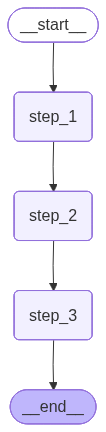

In [23]:
graph

In [24]:
try:
    print("▶️ Running graph: Please manually interrupt during Step 2...")
    graph.invoke({"input": "start"}, config={"configurable": {"thread_id": 'thread-1'}})
except KeyboardInterrupt:
    print("❌ Kernel manually interrupted (crash simulated).")

▶️ Running graph: Please manually interrupt during Step 2...
✅ Step 1 executed
⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)
❌ Kernel manually interrupted (crash simulated).


In [25]:
graph.get_state({"configurable": {"thread_id": 'thread-1'}})

StateSnapshot(values={'input': 'start', 'step1': 'done'}, next=('step_2',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f130feb-ca33-6e76-8001-0c5ee1d078e6'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-04-05T14:50:06.983712+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f130feb-ca2d-6ffb-8000-2f06e30718f6'}}, tasks=(PregelTask(id='969d81bc-06b6-c019-4fec-61d2b6a00d56', name='step_2', path=('__pregel_pull', 'step_2'), error=None, interrupts=(), state=None, result=None),), interrupts=())

Here running from None to resume from where it left off

In [26]:
# 6. Re-run to show fault-tolerant resume
print("\n🔁 Re-running the graph to demonstrate fault tolerance...")
final_state = graph.invoke(None, config={"configurable": {"thread_id": 'thread-1'}})
print("\n✅ Final State:", final_state)


🔁 Re-running the graph to demonstrate fault tolerance...
⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)
✅ Step 3 executed

✅ Final State: {'input': 'start', 'step1': 'done', 'step2': 'done', 'step3': 'done'}


In [29]:
graph.get_state({"configurable": {"thread_id": 'thread-1'}})

StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done', 'step3': 'done'}, next=(), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f130fef-7c7f-6471-8003-2ed5b7850e11'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-04-05T14:51:46.209876+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f130fef-7c7a-6590-8002-5bd396e41faf'}}, tasks=(), interrupts=())

In [28]:
list(graph.get_state_history({"configurable": {"thread_id": 'thread-1'}}))

[StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done', 'step3': 'done'}, next=(), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f130fef-7c7f-6471-8003-2ed5b7850e11'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-04-05T14:51:46.209876+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f130fef-7c7a-6590-8002-5bd396e41faf'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done'}, next=('step_3',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f130fef-7c7a-6590-8002-5bd396e41faf'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-04-05T14:51:46.207843+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f130feb-ca33-6e76-8001-0c5ee1d078e6'}}, tasks=(PregelTask(id='2e41afa5-ad64-c8bf